In [302]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [303]:
df = pd.read_csv("netflix1.csv")

In [304]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [305]:
df.shape

(8790, 10)

In [306]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [308]:
print(df.describe())

       release_year
count   8790.000000
mean    2014.183163
std        8.825466
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [309]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [310]:
df.duplicated().sum()

0

In [311]:
(df == 'Not Given').sum()


show_id            0
type               0
title              0
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64

In [312]:
df.replace(['Not Given', 'not given', 'Unknown'], np.nan, inplace=True)


In [313]:
df.isnull().sum()

show_id            0
type               0
title              1
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64

In [314]:
df = df.dropna(subset=['title'])


In [315]:
df['title'].value_counts()

title
9-Feb                   2
15-Aug                  2
22-Jul                  2
Dick Johnson Is Dead    1
SGT. Will Gardner       1
                       ..
The Burial of Kojo      1
Mercy Black             1
The Trap                1
Pinky Memsaab           1
YOM                     1
Name: count, Length: 8786, dtype: int64

In [316]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [317]:
df['year_added'] = df['date_added'].dt.year

In [318]:
df['month_added'] = df['date_added'].dt.month

In [319]:
df.loc[df['type'] == 'Movie', 'duration_min'] = (
    df.loc[df['type'] == 'Movie', 'duration']
      .str.extract(r'(\d+)')[0]
      .astype(float)
)
df.loc[df['type'] == 'TV Show', 'num_of_season'] = (
    df.loc[df['type'] == 'TV Show', 'duration']
      .str.extract(r'(\d+)')[0]
      .astype(float)
)


In [320]:
print(df.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States 2021-09-25          2020  PG-13    90 min   
1         France 2021-09-24          2021  TV-MA  1 Season   
2  United States 2021-09-24          2021  TV-MA  1 Season   
3         Brazil 2021-09-22          2021  TV-PG    91 min   
4  United States 2021-09-24          1993  TV-MA   125 min   

                                           listed_in  year_added  month_added  \
0                                      Documentaries        2021            9   
1  Crime TV Shows, Interna

In [321]:
df.isnull().sum()

show_id             0
type                0
title               0
director         2588
country           287
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
year_added          0
month_added         0
duration_min     2664
num_of_season    6125
dtype: int64

In [322]:
df['listed_in_split'] = df['listed_in'].str.split(r',\s*|\s*&\s*')


In [323]:
df_genre =df.explode('listed_in_split')

In [324]:
print(df_genre.head())

  show_id     type                 title         director        country  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson  United States   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   

  date_added  release_year rating  duration  \
0 2021-09-25          2020  PG-13    90 min   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   

                                           listed_in  year_added  month_added  \
0                                      Documentaries        2021            9   
1  Crime TV Shows, International TV Shows, TV Act...        2021            9   
1  Crime TV Shows

In [325]:
df_genre['listed_in_split']=df_genre['listed_in_split'].str.strip()

In [326]:
df_genre['listed_in_split'].value_counts()

listed_in_split
International Movies         2752
Dramas                       2426
Comedies                     1674
International TV Shows       1349
Adventure                    1025
Documentaries                 869
Action                        858
TV Dramas                     762
Independent Movies            756
Children                      641
Family Movies                 641
Romantic Movies               616
Thrillers                     576
TV Comedies                   573
Crime TV Shows                469
Kids' TV                      448
Stand-Up Comedy               399
Docuseries                    394
Music                         375
Musicals                      375
Romantic TV Shows             370
Horror Movies                 357
Fantasy                       326
Reality TV                    255
British TV Shows              252
Sci-Fi                        243
Sports Movies                 219
Anime Series                  174
Spanish-Language TV Shows     17

In [327]:
df_genre['Movie_genre'] = df_genre['listed_in_split'].where(df_genre['type'] == 'Movie')


In [328]:
df_genre['TV show_genre'] = df_genre['listed_in_split'].where(df_genre['type'] == 'TV Show')

In [329]:
df_genre.loc[df_genre['type'] == 'Movie', 'num_of_season'] = 0
df_genre.loc[df_genre['type'] == 'TV Show', 'duration_min'] = 0


In [330]:
print(df_genre.head())

  show_id     type                 title         director        country  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson  United States   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   
1      s3  TV Show             Ganglands  Julien Leclercq         France   

  date_added  release_year rating  duration  \
0 2021-09-25          2020  PG-13    90 min   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   
1 2021-09-24          2021  TV-MA  1 Season   

                                           listed_in  year_added  month_added  \
0                                      Documentaries        2021            9   
1  Crime TV Shows, International TV Shows, TV Act...        2021            9   
1  Crime TV Shows

In [332]:
df_genre.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_min,num_of_season,listed_in_split,Movie_genre,TV show_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90.0,0.0,Documentaries,Documentaries,NaN
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,0.0,1.0,Crime TV Shows,NaN,Crime TV Shows
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,0.0,1.0,International TV Shows,NaN,International TV Shows
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,0.0,1.0,TV Action,NaN,TV Action
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,0.0,1.0,Adventure,NaN,Adventure


In [333]:
df_genre.to_csv('netflix_cleaned.csv',index=False)


In [335]:
#EDA

In [336]:
df_genre['rating'].value_counts()

rating
TV-MA       7851
TV-14       5754
TV-PG       2180
R           1873
PG-13       1266
PG           881
TV-Y7        691
TV-G         547
TV-Y         527
NR           176
G            115
TV-Y7-FV      21
UR             9
NC-17          7
Name: count, dtype: int64

In [337]:
#Rating count of netflix data

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'TV-MA'),
  Text(1, 0, 'TV-14'),
  Text(2, 0, 'TV-PG'),
  Text(3, 0, 'R'),
  Text(4, 0, 'PG-13'),
  Text(5, 0, 'PG'),
  Text(6, 0, 'TV-Y7'),
  Text(7, 0, 'TV-G'),
  Text(8, 0, 'TV-Y'),
  Text(9, 0, 'NR'),
  Text(10, 0, 'G'),
  Text(11, 0, 'TV-Y7-FV'),
  Text(12, 0, 'UR'),
  Text(13, 0, 'NC-17')])

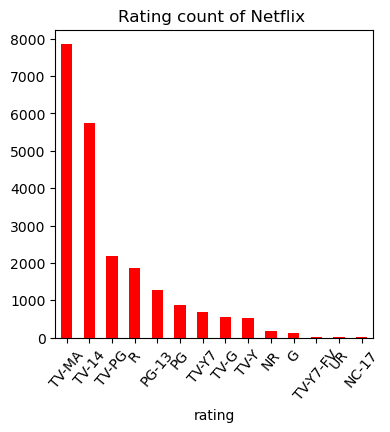

In [338]:
plt.figure(figsize=(4.1,4))
df_genre['rating'].value_counts().plot(kind='bar',color='red')
plt.title('Rating count of Netflix ')
plt.xticks(rotation=50)
plt.show()

In [339]:
#count of movies vs tv shows


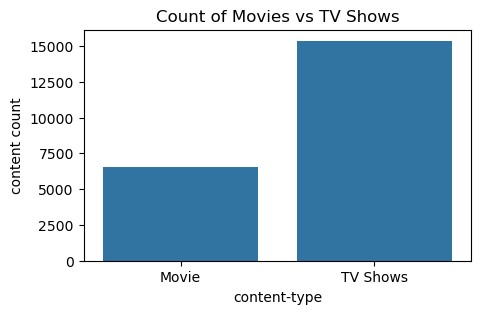

In [340]:
movie_count = df_genre['listed_in_split'].where(df_genre['type']=='TV Show').count()
Shows_count =df_genre['listed_in_split'].where(df_genre['type']=='Movie').count()
count_df = pd.DataFrame({
    'content-type':['Movie','TV Shows'],
    'content count':[movie_count,Shows_count]
})
plt.figure(figsize=(5,3))
sns.barplot(data=count_df,x='content-type',y='content count')
plt.title('Count of Movies vs TV Shows')
plt.show()

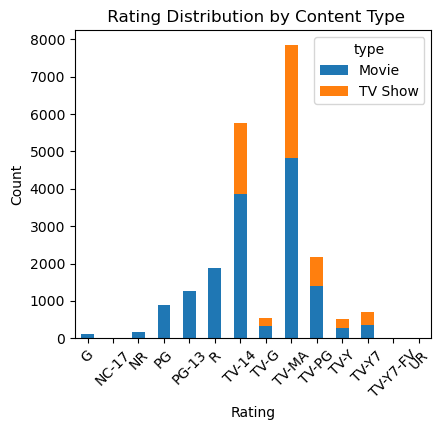

In [341]:
#rating split by movies vs tv shows
rating_pivot = pd.crosstab(df_genre['rating'], df_genre['type'])
rating_pivot.plot(kind='bar',stacked=True,figsize=(4.6,4))
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title(' Rating Distribution by Content Type')
plt.xticks(rotation=45)
plt.show()


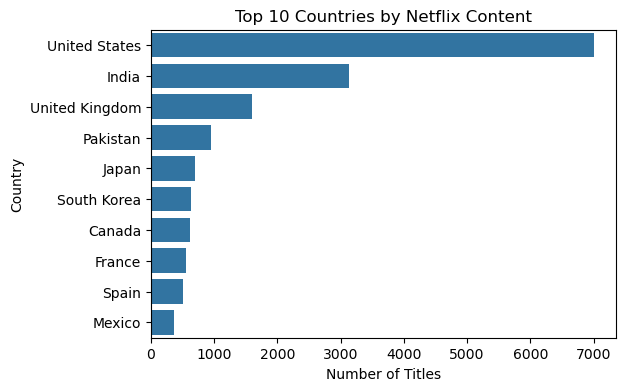

In [342]:
#top 10 countries by content
top_10_countries = (df_genre['country'].value_counts().head(10).reset_index())

top_10_countries.columns = ['Country', 'Content_Count']
plt.figure(figsize=(6,4))
sns.barplot(
    data=top_10_countries,
    x='Content_Count',
    y='Country'
)

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()


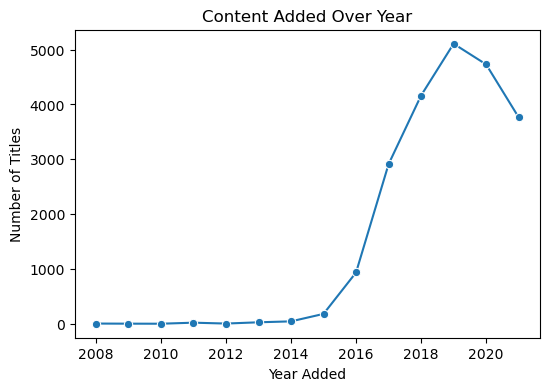

In [343]:
#content added over years
import seaborn as sns
import matplotlib.pyplot as plt
year_count = df_genre.groupby('year_added').size().reset_index(name='content_count')
plt.figure(figsize=(6,4))
sns.lineplot(data=year_count,x='year_added',y='content_count',marker='o')
plt.title("Content Added Over Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


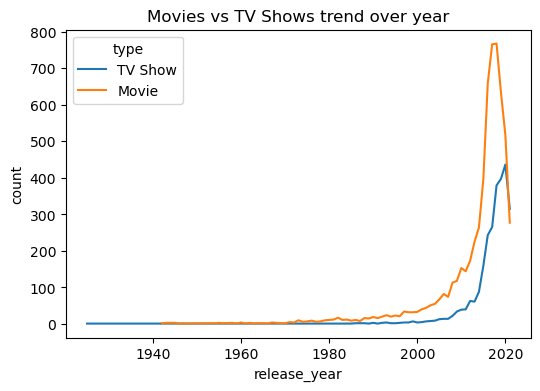

In [344]:
#movies vs tv shows trend over year
plt.figure(figsize=(6,4))
year_type_count = (df.groupby(['release_year', 'type']).size().reset_index(name='count'))
sns.lineplot(data = year_type_count,x='release_year',y = 'count',hue='type')
plt.title("Movies vs TV Shows trend over year")
plt.show()


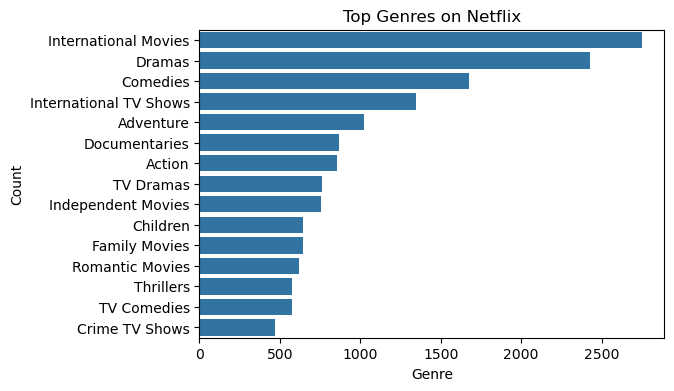

In [345]:
top_genres = df_genre['listed_in_split'].value_counts().head(15).reset_index(name = 'genre_count')
top_genres.columns=['genre','genre_count']
plt.figure(figsize=(6,4))
sns.barplot(data = top_genres,x='genre_count',y='genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top Genres on Netflix')
plt.show()

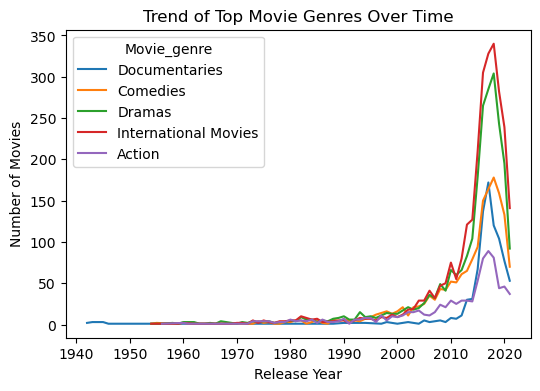

In [346]:
#Trend of Top Movie Genres Over Time
movie_df = df_genre[df_genre['type'] == 'Movie']
top_movie_genres = movie_df['Movie_genre'].value_counts().head(5).index
movie_filtered = movie_df[movie_df['Movie_genre'].isin(top_movie_genres)]
movie_genre_year = (movie_filtered.groupby(['release_year', 'Movie_genre']).size().reset_index(name='count'))
plt.figure(figsize=(6,4))
sns.lineplot(data=movie_genre_year,x='release_year',y='count',hue='Movie_genre')
plt.title('Trend of Top Movie Genres Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.show()


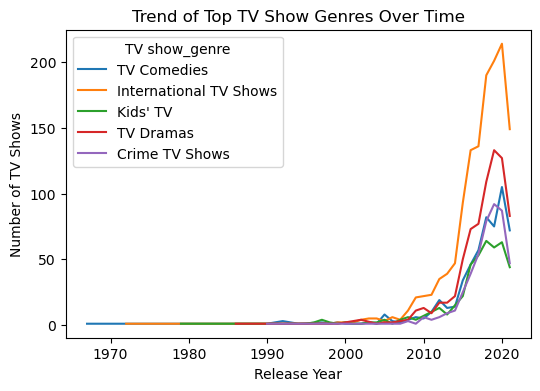

In [347]:
#Trend of Top TV Shows Genre Over Time
tv_df = df_genre[df_genre['type'] == 'TV Show']
top_tv_genres = tv_df['TV show_genre'].value_counts().head(5).index
tv_filtered = tv_df[tv_df['TV show_genre'].isin(top_tv_genres)]
tv_genre_year = (tv_filtered.groupby(['release_year', 'TV show_genre']).size().reset_index(name='count'))
plt.figure(figsize=(6,4))
sns.lineplot(
    data=tv_genre_year,
    x='release_year',
    y='count',
    hue='TV show_genre'
)
plt.title('Trend of Top TV Show Genres Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of TV Shows')
plt.show()


Text(0.5, 1.0, 'Number of TV Shows Season Distribution')

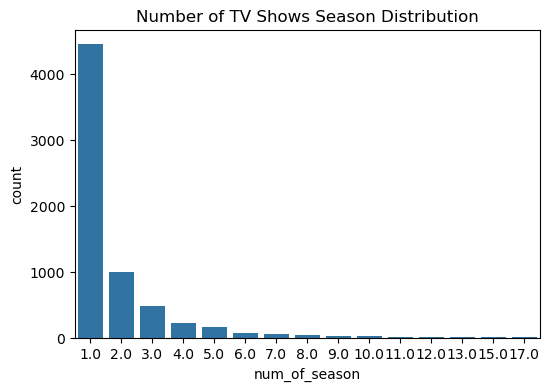

In [348]:
#Number of TV Shows Season distribution
plt.figure(figsize=(6,4))
sns.countplot(data = df_genre[df_genre['type'] == 'TV Show'],x = 'num_of_season')
plt.title('Number of TV Shows Season Distribution')


Text(0.5, 1.0, 'Top Genres by Content type')

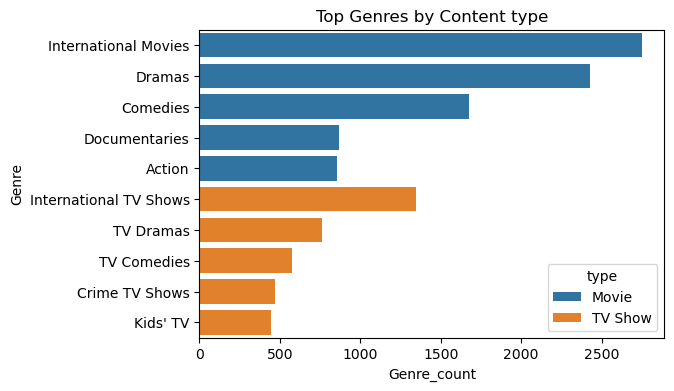

In [349]:
#top genres by content type
genre_type_count =(df_genre.groupby(['type','listed_in_split']).size().reset_index(name='count'))
top_genres_by_type =(genre_type_count.sort_values(['type','count'],ascending=[True,False]).groupby('type').head(5))
plt.figure(figsize=(6,4))
sns.barplot(data=top_genres_by_type,x='count',y='listed_in_split',hue='type')
plt.xlabel('Genre_count')
plt.ylabel('Genre')
plt.title('Top Genres by Content type')

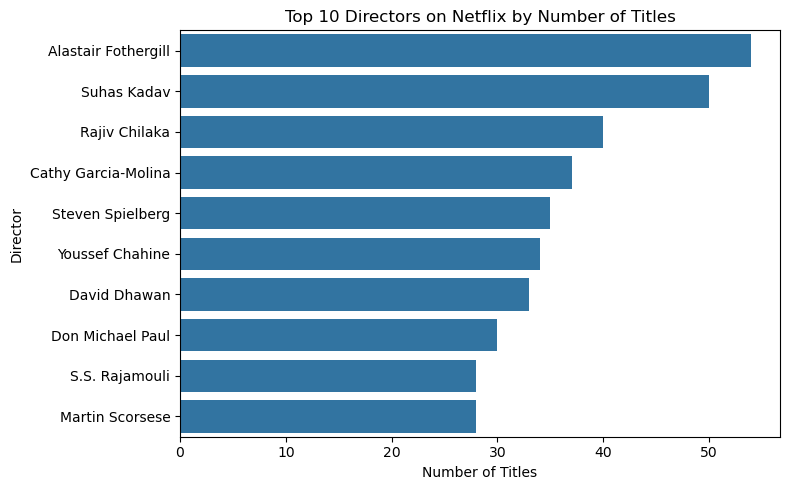

In [350]:
#Top 10 Directors on Netflix by Number of Titles
director_df = df_genre.dropna(subset=['director'])


top_directors = (director_df['director'].value_counts().head(10).reset_index())

top_directors.columns = ['director', 'title_count']

plt.figure(figsize=(8,5))
sns.barplot(data=top_directors,x='title_count',y='director')

plt.title('Top 10 Directors on Netflix by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()


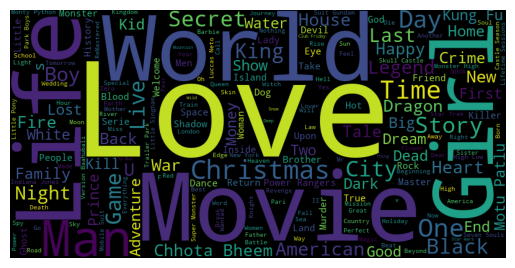

In [351]:
from wordcloud import WordCloud
text = " ".join(df_genre['title'].dropna())
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [352]:
df_genre['director'] = df_genre['director'].fillna('Unknown')
df_genre['country'] = df_genre['country'].fillna('Unknown')


In [356]:
df_genre = df_genre.dropna(subset=['title'])


In [357]:
df_genre['title_clean'] = (df_genre['title'].str.lower().str.strip())


In [358]:
netflix_df = (df_genre.drop_duplicates(subset='title_clean').reset_index(drop=True))


In [359]:
netflix_df['content_features'] = (netflix_df['listed_in_split'].fillna('') + ' ' +netflix_df['type'].fillna(''))


In [433]:
print(netflix_df.head())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States 2021-09-25          2020  PG-13    90 min   
1         France 2021-09-24          2021  TV-MA  1 Season   
2  United States 2021-09-24          2021  TV-MA  1 Season   
3         Brazil 2021-09-22          2021  TV-PG    91 min   
4  United States 2021-09-24          1993  TV-MA   125 min   

                                           listed_in  year_added  month_added  \
0                                      Documentaries        2021            9   
1  Crime TV Shows, Interna

In [361]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(netflix_df['content_features'])


In [363]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)


In [364]:
def recommend(title, df, similarity_matrix, top_n=5):

    title = title.lower().strip()

    if title not in df['title_clean'].values:
        return "Title not found"

    idx = df[df['title_clean'] == title].index[0]

    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    indices = [i[0] for i in sim_scores[1:top_n+1]]

    return df[['title', 'type', 'listed_in_split']].iloc[indices]


In [431]:
print(recommend("sankofa", netflix_df, cosine_sim, top_n=3))


               title   type listed_in_split
8       Je Suis Karl  Movie          Dramas
12  99 Songs (Tamil)  Movie          Dramas
54   Ankahi Kahaniya  Movie          Dramas
